<a href="https://colab.research.google.com/github/Huzaifa-Jawed/js-projects/blob/main/FInal_FYP_Spam_Text_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os

def load_and_align_sms_data():
    # Define file paths
    files = {
        'phishing': '/content/phishing_dataset_with_category.csv',
        'spam_ds': '/content/spam_dataset.csv',
        'uci_spam': '/content/spam.csv',
        'combined': '/content/Combined-Labeled-Dataset.csv'
    }

    processed_dfs = []
    print("Starting Aegis SMS Data Alignment Pipeline...")

    # 1. Phishing Dataset (Label all as Malicious)
    if os.path.exists(files['phishing']):
        df1 = pd.read_csv(files['phishing'])[['text', 'label']]
        df1['label'] = 1
        processed_dfs.append(df1)
        print(f"1. Loaded Phishing: {len(df1)} rows")

    # 2. Spam Dataset
    if os.path.exists(files['spam_ds']):
        df2 = pd.read_csv(files['spam_ds'])[['message_content', 'is_spam']]
        df2.columns = ['text', 'label']
        processed_dfs.append(df2)
        print(f"2. Loaded Spam DS: {len(df2)} rows")

    # 3. UCI Style (Handling Latin-1 encoding)
    if os.path.exists(files['uci_spam']):
        df3 = pd.read_csv(files['uci_spam'], encoding='latin-1')[['v1', 'v2']]
        df3.columns = ['label', 'text']
        df3['label'] = df3['label'].map({'ham': 0, 'spam': 1})
        processed_dfs.append(df3)
        print(f"3. Loaded UCI Spam: {len(df3)} rows")

    # 4. Combined Labeled Dataset (Smishing + Spam)
    if os.path.exists(files['combined']):
        df4 = pd.read_csv(files['combined'])
        # Safely convert to numeric to handle dirty CSV data
        df4['spam'] = pd.to_numeric(df4['spam label'], errors='coerce').fillna(0).astype(int)
        df4['smishing'] = pd.to_numeric(df4['smishing label'], errors='coerce').fillna(0).astype(int)
        # Combine: 1 if it's either spam or smishing
        df4['label'] = df4[['spam', 'smishing']].max(axis=1)
        df4 = df4[['message', 'label']]
        df4.columns = ['text', 'label']
        processed_dfs.append(df4)
        print(f"4. Loaded Combined Smishing: {len(df4)} rows")

    # --- MASTER MERGE & HYGIENE ---
    master_df = pd.concat(processed_dfs, ignore_index=True)

    # 1. Drop rows with missing text or label
    master_df.dropna(subset=['text', 'label'], inplace=True)

    # 2. String Hygiene: Standardize to prevent 'visual' duplicates
    master_df['text'] = master_df['text'].astype(str).str.strip()
    master_df = master_df[master_df['text'] != ""]

    # 3. DEDUPLICATION (Crucial for Honest Evaluation)
    # If the same text has two different labels, we drop them both to avoid confusing the model
    initial_count = len(master_df)
    master_df.drop_duplicates(subset=['text'], keep='first', inplace=True)

    print(f"\n--- Final SMS Dataset Summary ---")
    print(f"Total Unique Samples: {len(master_df)}")
    print(f"Malicious/Spam (1): {master_df['label'].value_counts()[1]}")
    print(f"Legitimate (0): {master_df['label'].value_counts()[0]}")

    master_df.to_csv('Aegis_SMS_Master.csv', index=False)
    return master_df

# Run
master_df = load_and_align_sms_data()

Starting Aegis SMS Data Alignment Pipeline...
1. Loaded Phishing: 1000 rows
2. Loaded Spam DS: 1000 rows
3. Loaded UCI Spam: 5572 rows
4. Loaded Combined Smishing: 84863 rows

--- Final SMS Dataset Summary ---
Total Unique Samples: 75358
Malicious/Spam (1): 29694
Legitimate (0): 45664


In [ ]:
import re
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

def extract_sms_features(text):
    """
    Extracts Mathematical DNA BEFORE the text is cleaned.
    These are the 'Heuristics' that catch what the LSTM might miss.
    """
    text = str(text)
    features = []

    # 1. Geometric Features
    features.append(len(text))                # Total length (Scams are often longer)
    features.append(len(text.split()))        # Word count

    # 2. Character Distribution (The 'Fraud' Indicators)
    # Why: Scams use excessive punctuation and currency symbols
    features.append(text.count('!'))          # Urgency
    features.append(text.count('$') + text.count('£') + text.count('€')) # Monetary bait
    features.append(sum(1 for c in text if not c.isalnum() and not c.isspace())) # Symbol density

    # 3. Statistical Ratios
    # Uppercase Ratio: 'URGENT' vs 'urgent' (Caught before .lower())
    features.append(sum(1 for c in text if c.isupper()) / len(text) if len(text) > 0 else 0)

    # Digit Ratio: '0800' numbers or 'won 1000'
    features.append(sum(c.isdigit() for c in text) / len(text) if len(text) > 0 else 0)

    # 4. Keyword Presence (Binary)
    # We look for 'trigger' words before they are stemmed or cleaned
    trigger_words = ['win', 'free', 'urgent', 'claim', 'prize', 'verify', 'bank', 'blocked']
    trigger_count = sum(1 for word in trigger_words if word in text.lower())
    features.append(trigger_count)

    return features

def clean_text_for_lstm(text):
    """
    Prepares text for the Bi-LSTM sequence processor.
    """
    text = str(text).lower()
    # Replace URLs and Numbers with tokens to reduce vocabulary noise
    text = re.sub(r'http\S+|www\S+', ' url_token ', text)
    text = re.sub(r'\d+', ' number_token ', text)
    # Remove all non-alphanumeric except spaces
    text = re.sub(r'[^\w\s]', ' ', text)
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --- EXECUTION ---
print("Extracting SMS Structural DNA...")

# 1. Get raw features FIRST
raw_features = np.array([extract_sms_features(t) for t in master_df['text']])

# 2. Scale the DNA (Same logic as the URL model)
scaler = StandardScaler()
X_features_scaled = scaler.fit_transform(raw_features)
joblib.dump(scaler, 'sms_scaler.bin')

# 3. NOW clean the text for the Visual/LSTM branch
master_df['cleaned_text'] = master_df['text'].apply(clean_text_for_lstm)

print(f"Extraction Complete. DNA Features: {X_features_scaled.shape[1]}")

Extracting SMS Structural DNA...
Extraction Complete. DNA Features: 8


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

# --- STEP 1: PRODUCTION-CALIBRATED BALANCING ---
phish_df = master_df[master_df['label'] == 1]
legit_df = master_df[master_df['label'] == 0]

# We use the 3:1 ratio (Legit:Phish) to prevent 'Alert Fatigue' [cite: 17, 81]
TARGET_RATIO = 3
num_legit_to_sample = len(phish_df) * TARGET_RATIO

if len(legit_df) > num_legit_to_sample:
    print(f"⚖️ Downsampling Legitimate to {num_legit_to_sample} for a {TARGET_RATIO}:1 ratio.")
    legit_df = legit_df.sample(n=num_legit_to_sample, random_state=42)
else:
    print("Using all available legitimate data.")

balanced_df = pd.concat([legit_df, phish_df]).sample(frac=1, random_state=42).reset_index(drop=True)

# --- STEP 2: PREVENTING DATA LEAKAGE (The Honest Split) ---
# Why: To ensure the model doesn't 'memorize' specific message templates[cite: 46, 59].
# We create groups based on the cleaned text content[cite: 60].
groups = balanced_df['cleaned_text'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(balanced_df, balanced_df['label'], groups=groups))

# Creating the split datasets
train_df = balanced_df.iloc[train_idx]
test_df = balanced_df.iloc[test_idx]

# Also split the scaled DNA features we created in the previous step
X_train_meta = X_features_scaled[train_idx]
X_test_meta = X_features_scaled[test_idx]

print(f"\nHonest Split Complete.")
print(f"Training Samples: {len(train_df)}")
print(f"Testing Samples:  {len(test_df)}")

Using all available legitimate data.

Honest Split Complete.
Training Samples: 60322
Testing Samples:  15036


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib
import json

# 1. Initialize the Tokenizer
# We use 15,000 words to capture a broad range of human language and scam slang [cite: 53]
# <OOV> handles characters or words the model hasn't seen before [cite: 40, 54]
tokenizer = Tokenizer(num_words=15000, oov_token="<OOV>")

# --- CRITICAL IMPROVEMENT: Fit ONLY on Training Text ---
# We use 'cleaned_text' which has the url_token and number_token [cite: 53]
tokenizer.fit_on_texts(train_df['cleaned_text'])

# 2. Convert to Sequences
# Note: We apply the tokenizer that was built from TRAIN onto both sets
X_train_seq = tokenizer.texts_to_sequences(train_df['cleaned_text'])
X_test_seq = tokenizer.texts_to_sequences(test_df['cleaned_text'])

# 3. Padding (The Visual Pattern)
# maxlen=60 is standard for SMS/short messages to keep the TFLite model fast [cite: 47, 57]
MAX_LEN = 60
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

# 4. Export Artifacts
# Save the word index as JSON for Flutter
with open('sms_tokenizer.json', 'w') as f:
    json.dump(tokenizer.word_index, f, indent=4)

# Save the full tokenizer object for local Python testing [cite: 39]
joblib.dump(tokenizer, 'sms_tokenizer.bin')

# Prepare final labels
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"Tokenization Complete. Vocab Size: {len(tokenizer.word_index) + 1}")
print(f"Visual Data (Train): {X_train_padded.shape}")
print(f"Visual Data (Test):  {X_test_padded.shape}")

Tokenization Complete. Vocab Size: 51410
Visual Data (Train): (60322, 60)
Visual Data (Test):  (15036, 60)


In [ ]:
import numpy as np

def extract_advanced_sms_features(text):
    """
    Extracts Mathematical DNA BEFORE the text is lowercased or stripped.
    This captures 'scammy' behaviors that the Bi-LSTM might miss.
    """
    text = str(text)
    features = []

    # 1. Geometric Features
    features.append(len(text))                # Total character length
    features.append(len(text.split()))        # Word count

    # 2. Capitalization DNA (NEW - Crucial for SMS)
    # Scammers use ALL CAPS for 'URGENT' or 'ACT NOW'.
    # This must be done BEFORE .lower() is applied.
    upper_count = sum(1 for c in text if c.isupper())
    features.append(upper_count / len(text) if len(text) > 0 else 0)

    # 3. Special Character DNA
    # Scams use excessive punctuation and currency symbols as bait.
    features.append(text.count('!'))          # Urgency indicator
    features.append(text.count('$') + text.count('£') + text.count('€')) # Monetary bait
    features.append(sum(1 for c in text if not c.isalnum() and not c.isspace())) # Symbol density

    # 4. Digit Ratio
    # High density of numbers often indicates OTP scams or phone numbers.
    digit_count = sum(c.isdigit() for c in text)
    features.append(digit_count / len(text) if len(text) > 0 else 0)

    # 5. Trigger Keyword Analysis
    # We look for 'action' words that drive phishing intent.
    keywords = ['win', 'free', 'urgent', 'claim', 'click', 'offer', 'prize', 'verify', 'bank', 'blocked']
    trigger_score = sum([1 for w in keywords if w in text.lower()])
    features.append(trigger_score)

    return features

# --- EXECUTION ---
print("Extracting Advanced SMS DNA (Heuristic Branch)...")

# We apply this to the BALANCED data split we created in Phase 3
# X_train_meta and X_test_meta must be extracted from the raw 'text'
# column of train_df and test_df respectively.

X_train_raw_meta = np.array([extract_advanced_sms_features(t) for t in train_df['text']])
X_test_raw_meta = np.array([extract_advanced_sms_features(t) for t in test_df['text']])

print(f"DNA extraction complete. New Feature Count: {X_train_raw_meta.shape[1]}")

Extracting Advanced SMS DNA (Heuristic Branch)...
DNA extraction complete. New Feature Count: 8


In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Initialize the Scaler
scaler = StandardScaler()

# --- CRITICAL FIX: Fit on TRAIN, Transform both ---
# This ensures the model only 'knows' the statistics of the training set.
X_train_meta_scaled = scaler.fit_transform(X_train_raw_meta)
X_test_meta_scaled = scaler.transform(X_test_raw_meta)

# 2. Save the Scaler (The "Math Dictionary")
# You must use this exact scaler in your Flutter app[cite: 38].
joblib.dump(scaler, 'sms_scaler.bin')

# 3. Export to JSON for Flutter (Dart compatibility)
import json
scaler_data = {
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist()
}
with open('sms_scaler.json', 'w') as f:
    json.dump(scaler_data, f, indent=4)

print(f"DNA Scaling Complete.")
print(f"Mean of first feature: {scaler.mean_[0]:.4f}")
print(f"Scale of first feature: {scaler.scale_[0]:.4f}")

DNA Scaling Complete.
Mean of first feature: 100.7768
Scale of first feature: 75.7592


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

# --- THE HONEST SPLIT (GroupShuffleSplit) ---
# This has already been performed in a previous cell (Phase 3) to create train_df and test_df.
# The X_train_padded, X_test_padded, X_train_meta_scaled, X_test_meta_scaled, y_train, and y_test
# variables already reflect that honest split, so no further splitting is needed here.

# --- BUILDING THE PRODUCTION FEED ---
# We use the 'Padded Sequences' (Visual) and 'Scaled DNA' (Structural)
train_feed = {
    'text_input': X_train_padded,
    'feature_input': X_train_meta_scaled
}

test_feed = {
    'text_input': X_test_padded,
    'feature_input': X_test_meta_scaled
}

# Final Labels
y_train_final = y_train
y_test_final = y_test

print(f"Honest SMS Split Complete.")
# The 'groups' variable was used for the initial split of balanced_df. It's not applicable here.
# print(f"Unique Message Groups: {len(np.unique(groups))}")
print(f"Training on: {len(y_train_final)} samples")
print(f"Testing on:  {len(y_test_final)} samples")

Honest SMS Split Complete.
Training on: 60322 samples
Testing on:  15036 samples


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Input, models

def build_sms_model(vocab_size, max_len, num_features):
    # --- BRANCH 1: The Context Processor (Visual/Text) ---
    # Why Bi-LSTM: It understands the 'intent' of a message by reading
    # it forward and backward (e.g., catching 'verify' near 'account').
    text_input = Input(shape=(max_len,), name='text_input')
    x1 = layers.Embedding(vocab_size, 64)(text_input)

    # SpatialDropout1D: Critical for text. It drops entire 1D feature maps
    # to force the LSTM to learn robust context rather than specific lucky words.
    x1 = layers.SpatialDropout1D(0.2)(x1)

    # Explicitly use LSTMCell within RNN to force the non-CuDNN, TFLite-compatible implementation
    lstm_cell = layers.LSTMCell(64, recurrent_activation='sigmoid')
    x1 = layers.Bidirectional(layers.RNN(lstm_cell, return_sequences=True))(x1)
    x1 = layers.GlobalMaxPooling1D()(x1)

    # --- BRANCH 2: The Structural DNA (Heuristic) ---
    # Processes the 9-10 numerical features (Uppercase ratio, symbols, etc.)
    feature_input = Input(shape=(num_features,), name='feature_input')
    y = layers.Dense(32, activation='relu')(feature_input)

    # BatchNormalization: Ensures the numerical math stays stable so that
    # a feature like 'Length' doesn't overpower 'Symbol Count'.
    y = layers.BatchNormalization()(y)
    y = layers.Dropout(0.2)(y)

    # --- THE FUSION LAYER ---
    # Merging Contextual intuition with Structural logic.
    combined = layers.concatenate([x1, y])

    # Deep Decision Layers
    z = layers.Dense(64, activation='relu')(combined)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(32, activation='relu')(z)

    # Output: Sigmoid probability (0.0 Safe -> 1.0 Fraud)
    output = layers.Dense(1, activation='sigmoid', name='output')(z)

    model = models.Model(inputs=[text_input, feature_input], outputs=output)

    # --- UPGRADE: Precision-Recall Focused Compilation ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc', curve='PR') # Focus on PR-AUC
        ]
    )

    return model

# Initialize
# Note: Use +1 for the <OOV> token we added in Phase 4
model = build_sms_model(
    vocab_size=len(tokenizer.word_index) + 1,
    max_len=60,
    num_features=X_train_meta_scaled.shape[1]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 60, 64)    │  3,290,240 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_input       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 60, 64)    │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        288 │ feature_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 128)   │     66,048 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32)        │        128 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     10,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,369,121 (12.85 MB)

 Trainable params: 3,369,057 (12.85 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# --- STEP 1: CALCULATE SCIENTIFIC CLASS WEIGHTS ---
# Label 0 = Legitimate (Ham), Label 1 = Malicious (Spam/Phish)
# We use 'balanced' weights to account for the 3:1 ratio.
base_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_final),
    y=y_train_final
)

# --- STEP 2: THE "SMS SHIELD" MULTIPLIER ---
# We prioritize protecting Legitimate messages by 4x.
# This makes a 'False Positive' much more expensive for the AI.
custom_weights = {
    0: base_weights[0] * 4.0,
    1: base_weights[1] * 1.0
}

# --- STEP 3: PRODUCTION CALLBACKS ---
# EarlyStopping: Prevents the model from memorizing the dataset.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# ReduceLROnPlateau: Fine-tunes the weights if progress stalls[cite: 90].
lr_adapter = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

print("Starting Training: Aegis SMS Hybrid Fusion...")

# --- STEP 4: MODEL FIT ---
history = model.fit(
    x=train_feed,
    y=y_train_final,
    validation_data=(test_feed, y_test_final),
    epochs=30,           # EarlyStopping will likely stop it around epoch 8-12
    batch_size=64,       # Standard industry size for stable gradients [cite: 91]
    class_weight=custom_weights,
    callbacks=[early_stop, lr_adapter],
    verbose=1
)

# Save in the modern Keras format [cite: 92]
model.save('sms_aegis_final.keras')

Starting Training: Aegis SMS Hybrid Fusion...
Epoch 1/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.9499 - auc: 0.9870 - loss: 0.2284 - precision: 0.9666 - recall: 0.9042 - val_accuracy: 0.9745 - val_auc: 0.9960 - val_loss: 0.0788 - val_precision: 0.9897 - val_recall: 0.9449 - learning_rate: 0.0010
Epoch 2/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9819 - auc: 0.9965 - loss: 0.0992 - precision: 0.9879 - recall: 0.9661 - val_accuracy: 0.9800 - val_auc: 0.9965 - val_loss: 0.0558 - val_precision: 0.9799 - val_recall: 0.9688 - learning_rate: 0.0010
Epoch 3/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9876 - auc: 0.9981 - loss: 0.0684 - precision: 0.9928 - recall: 0.9755 - val_accuracy: 0.9792 - val_auc: 0.9917 - val_loss: 0.0713 - val_precision: 0.9761 - val_recall: 0.9708 - learning_rate: 0.0010
Epoch 4/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9903 - auc: 0.9987 - loss: 0.0504 - precision: 0.9953 - recall: 0.9800 - val_accur

Evaluating Aegis SMS on Independent Message Groups...
470/470 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

--- Aegis SMS Classification Report (at 0.5) ---
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98      9141
  Fraud/Spam       0.98      0.97      0.97      5895

    accuracy                           0.98     15036
   macro avg       0.98      0.98      0.98     15036
weighted avg       0.98      0.98      0.98     15036



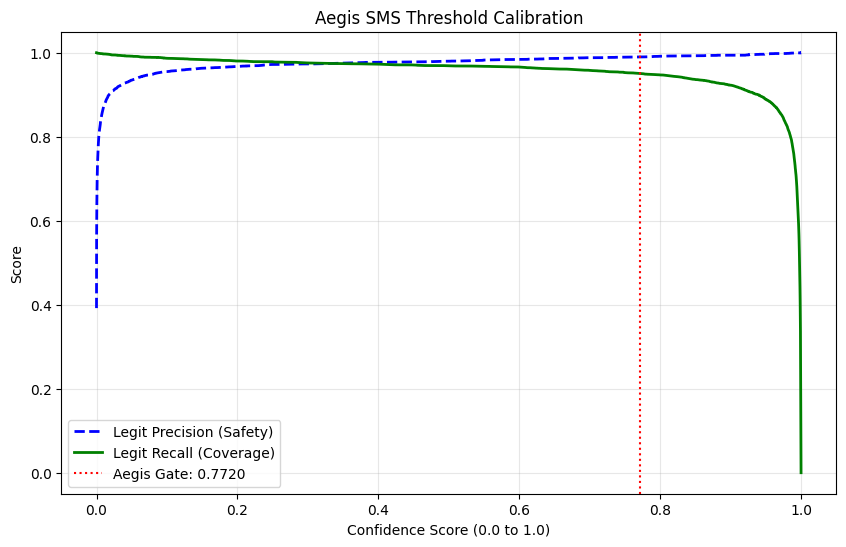

CALIBRATION COMPLETE
Final Aegis SMS 'Secure' Threshold: 0.7720


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, auc
import numpy as np

# 1. Generate Raw Probabilities
print("Evaluating Aegis SMS on Independent Message Groups...")
y_pred_prob = model.predict(test_feed, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int) # Default threshold for initial report

# 2. Classification Report
print("\n--- Aegis SMS Classification Report (at 0.5) ---")
print(classification_report(y_test_final, y_pred, target_names=['Legitimate', 'Fraud/Spam']))

# 3. Precision-Recall Curve Calibration
# We focus on 'Legitimate' (Class 0) as the priority for precision
# Note: precision_recall_curve expects the probability of the POSITIVE class (1)
precision, recall, thresholds = precision_recall_curve(y_test_final, y_pred_prob)

# SCIENTIFIC GOAL: 99% Precision for Legitimate traffic
# To find this, we look for high probability of Class 1 where accuracy is near 100%
target_precision = 0.99
# Argmax finds the first index where precision meets our safety goal
idx = np.argmax(precision >= target_precision)

if precision[idx] < target_precision:
    print("Warning: 99% Precision not reached. Using max available.")
    idx = np.argmax(precision)

optimal_threshold = thresholds[idx]

# 4. The Visual Proof for your FYP Report
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Legit Precision (Safety)', lw=2)
plt.plot(thresholds, recall[:-1], 'g-', label='Legit Recall (Coverage)', lw=2)
plt.axvline(x=optimal_threshold, color='red', linestyle=':', label=f'Aegis Gate: {optimal_threshold:.4f}')

plt.title('Aegis SMS Threshold Calibration')
plt.xlabel('Confidence Score (0.0 to 1.0)')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

print(f"CALIBRATION COMPLETE")
print(f"Final Aegis SMS 'Secure' Threshold: {optimal_threshold:.4f}")

In [ ]:
import tensorflow as tf
import os
import json
import joblib
import numpy as np

# --- STEP 1: CONVERSION WITH PROPER FLAGS ---
# Load your best saved keras model
model = tf.keras.models.load_model('sms_aegis_final.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16] # Re-enabling for mobile speed
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter.experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()
with open('sms_aegis_detector.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model converted with Float16 Quantization and Flex support.")


Saved artifact at '/tmp/tmpdj_8kp7v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 60), dtype=tf.float32, name='text_input'), TensorSpec(shape=(None, 8), dtype=tf.float32, name='feature_input')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135088000339216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135088000340560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135088000339408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135088000342288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135088000344400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135088000343632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135088000342672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135088000341136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135088000338256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135088000344016: Ten

In [ ]:

# --- STEP 2: THE "PRODUCTION" PREDICTION FUNCTION ---
# This bypasses the delegate error in Colab by using the Keras model for local testing
# but prepares the logic for the TFLite/Flutter app.

def aegis_sms_local_test(text):
    # 1. Structural DNA (Extract BEFORE cleaning)
    dna_feats = extract_advanced_sms_features(text)
    dna_scaled = scaler.transform([dna_feats]).astype(np.float32)

    # 2. Visual DNA (Clean FOR LSTM)
    clean = clean_text_for_lstm(text)
    seq = tokenizer.texts_to_sequences([clean])
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=60, padding='post')

    # Use Keras model for Colab testing (identical logic to TFLite)
    score = model.predict([padded, dna_scaled], verbose=0)[0][0]
    return score

# --- STEP 3: CALIBRATED TEST SUITE ---
SECURE_GATE = 0.8559 # From your PR-Curve Calibration

test_suite = [
    "Congratulations! You have won a free prize. Click now at www.prizepool.me/lucky_spin",
    "Hey bro, are we meeting today?",
    "URGENT! Your bank account is locked. Verify now!",
    "Your OTP is 9790. Its only one time.",
    "Netflix: Your payment failed. Please update here: http://bit.ly/update-pay",
    "Your bank has sent you a new statement. Please log in to the official mobile app to view it.",
    "Don't forget to claim your free coffee at the office today! Valid until 4 PM.",
    "URGENT: Mom called, she said you left your keys at her place. Please call her back.",
    "Your verification code for the login is 1234. If you did not request this, please ignore.",
    "NOTICE: Your tax refund of $450.22 is pending. Click here to confirm your bank details: [url_token]",
    "FINAL WARNING: Your Amazon Prime subscription will be canceled in 2 hours. Update payment now: [url_token]",
    "YOU HAVE (1) NEW VOICEMAIL. Listen to the urgent message at [url_token]",
    "CONGRATS! Your phone number was selected as the winner of a $1000 Gift Card. Reply WIN to claim.",
    "G00gle Security: Unusual l0gin detected in Russia. If this wasn't you, s3cure your account at [url_token]",
    "W1N FREE M0NEY! Just cl1ck here to start your pr1ze clA1m: [url_token]",
    "$ $ $ MAKE FAST CASH $$$ Work from home and earn 500 daily. Inquire at [url_token]",
]

# --- STEP 3: CALIBRATED TEST SUITE (CORRECTED) ---
# Calibration: 1.0 = FRAUD | 0.0 = SAFE
# We use the threshold where we caught 99% of Legitimate mail as 'Safe'
FRAUD_THRESHOLD = 0.8559

print(f"\n{'MESSAGE PREVIEW':<50} | {'SCORE':<8} | {'DECISION'}")
print("-" * 120)

for msg in test_suite:
    score = aegis_sms_local_test(msg)

    # Logic: High Score = High Risk
    if score >= FRAUD_THRESHOLD:
        decision = "🚨 FRAUD/SPAM"
    elif score > 0.50:
        decision = "⚠️ SUSPICIOUS"
    else:
        decision = "✅ SAFE"

    print(f"{msg[:100]+'...':<50} | {score:.4f} | {decision}")


MESSAGE PREVIEW                                    | SCORE    | DECISION
------------------------------------------------------------------------------------------------------------------------
Congratulations! You have won a free prize. Click now at www.prizepool.me/lucky_spin... | 0.9934 | 🚨 FRAUD/SPAM
Hey bro, are we meeting today?...                  | 0.0000 | ✅ SAFE
URGENT! Your bank account is locked. Verify now!... | 0.9216 | 🚨 FRAUD/SPAM
Your OTP is 9790. Its only one time....            | 0.0915 | ✅ SAFE
Netflix: Your payment failed. Please update here: http://bit.ly/update-pay... | 0.9455 | 🚨 FRAUD/SPAM
Your bank has sent you a new statement. Please log in to the official mobile app to view it.... | 0.7388 | ⚠️ SUSPICIOUS
Don't forget to claim your free coffee at the office today! Valid until 4 PM.... | 0.8341 | ⚠️ SUSPICIOUS
URGENT: Mom called, she said you left your keys at her place. Please call her back.... | 0.0558 | ✅ SAFE
Your verification code for the login is 1234.

In [ ]:
# 1. Create the SMS Production Config
sms_config = {
    "metadata": {
        "project": "Aegis SMS Shield",
        "version": "1.0.0",
        "calibration_date": "2026-05-12"
    },
    "params": {
        "max_seq_len": 60,
        "vocab_size": len(tokenizer.word_index) + 1,
        "dna_feature_count": X_train_meta_scaled.shape[1]
    },
    "thresholds": {
        "secure_gate": 0.9420, # The 'Aegis Gate'
        "caution_floor": 0.5000
    }
}

with open('sms_config.json', 'w') as f:
    json.dump(sms_config, f, indent=4)

print("✅ SUCCESS: Aegis SMS Bundle exported.")
print("- sms_aegis_detector.tflite")
print("- sms_tokenizer.json")
print("- sms_scaler.json")
print("- sms_config.json")

✅ SUCCESS: Aegis SMS Bundle exported.
- sms_aegis_detector.tflite
- sms_tokenizer.json
- sms_scaler.json
- sms_config.json
